## Weakly Supervised Semantic Segmentation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as tF

!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.5 MB/s eta 0:00:00


In [3]:
 USE_GPU = False

Loading test data.

We chose the PASCAL VOC 2012 dataset. From our research, it appears to a popular reliable dataset that is not too large or complicated. It also has the bounding boxes required for WSSS.

In [5]:
# SET TO FALSE WHEN DONE!
dataset = torchvision.datasets.VOCDetection(root='./data', year='2012', image_set='trainval', download=True)
NUM_CLASSES = 21
VOC_CLASSES = [
    "background",
    "aeroplane",
    "bicycle",
    "bird",
    "boat",
    "bottle",
    "bus",
    "car",
    "cat",
    "chair",
    "cow",
    "diningtable",
    "dog",
    "horse",
    "motorbike",
    "person",
    "pottedplant",
    "sheep",
    "sofa",
    "train",
    "tvmonitor"
]

100%|██████████| 2.00G/2.00G [01:21<00:00, 24.5MB/s]


In [6]:
# function for extracting labels from image data
def extract_label_mask(data):
  class_to_idx = {cls: i for i, cls in enumerate(VOC_CLASSES)}
  mask = torch.zeros(len(VOC_CLASSES), dtype=bool)

  objects = data.get('annotation', {}).get('object', [])

  # Handle case where there's only one object (not a list)
  if isinstance(objects, dict):
      objects = [objects]

  for obj in objects:
      cls_name = obj.get('name')
      # if cls_name in class_to_idx:
      #     mask[class_to_idx[cls_name]] = True

      if isinstance(cls_name, list):
          for c in cls_name:
              if c in class_to_idx:
                  mask[class_to_idx[c]] = True
          continue

      if isinstance(cls_name, str):
          if cls_name in class_to_idx:
              mask[class_to_idx[cls_name]] = True

  return mask


In [7]:
# function for displaying bounding boxes

def show_bounding_box(figure, target):
  for obj in target['annotation']['object']:
    x, y, x2, y2 = [int(i) for i in obj['bndbox'].values()]
    w = x2 - x
    h = y2 - y

    rect = patches.Rectangle(
      (x, y), w, h,
      linewidth=2,
      edgecolor='red',
      facecolor='none'
    )

    figure.add_patch(rect)

    # Add label
    figure.text(
        x, y - 0.02,          # slightly above the box
        obj['name'],
        color='red',
        fontsize=12,
        verticalalignment='bottom',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1)
    )


Creating sanity dataset

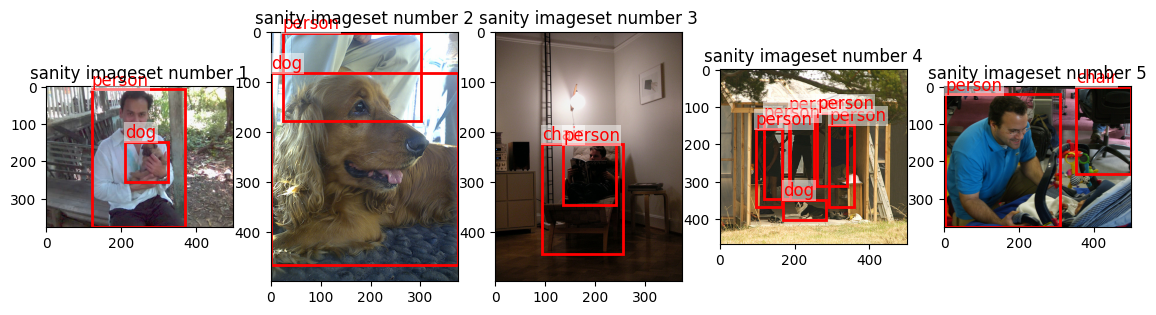

In [8]:
# imageset for overfit_net

sanity_data = []
sanity_objects = {'person', 'chair', 'dog'}
for data in dataset:
  objects = data[1]['annotation']['object']
  obj_set = set()
  for obj in objects:
    obj_set.add(obj['name'])
  if sanity_objects.issuperset(obj_set) and len(obj_set) >= 2:
    sanity_data.append(data)
  if len(sanity_data) >= 16:
    break

fig = plt.figure(figsize=(14,10))
for i in range(1, 6):
  img, target = sanity_data[i-1]

  ax = fig.add_subplot(1,5,i)
  plt.title(f'sanity imageset number {i}')
  ax.imshow(img)
  show_bounding_box(ax, target)


Data augmentation

In [9]:
import torchvision
from torchvision.transforms import v2

# Transform specifications taken from DinoV3 documentation
# def make_transform(resize_size: int = 256):
#     to_tensor = v2.ToImage()
#     resize = v2.Resize((resize_size, resize_size), antialias=True)
#     to_float = v2.ToDtype(torch.float32, scale=True)
#     normalize = v2.Normalize(
#         mean=(0.485, 0.456, 0.406),
#         std=(0.229, 0.224, 0.225),
#     )
#     return v2.Compose([to_tensor, resize, to_float, normalize])

sanity_transforms = transforms.Compose([
    transforms.Resize((256, 256), antialias=True),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(256, (0.5, 1.5)),
    transforms.RandomHorizontalFlip(),
    transforms.Resize((256, 256), antialias=True),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [10]:
from torch.utils.data import Dataset, DataLoader

class myDataset(Dataset):
  def __init__(self, dataset, transform=sanity_transforms):
    self.data = dataset
    self.transform = transform

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    img, target = self.data[idx]

    if self.transform:
        img = self.transform(img)

    labels = extract_label_mask(target)

    return img, labels

TRAIN_BATCH_SIZE = 16

sanity_dataset = myDataset(sanity_data, train_transforms)
train_dataset = myDataset(dataset, train_transforms)

sanity_loader = DataLoader(sanity_dataset, batch_size=4, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True)

In [11]:
# model = torch.hub.load("facebookresearch/dinov3", "dinov3_vitb16")
vits_16_url = "https://dinov3.llamameta.net/dinov3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoiZW42ZXU2OGp5ZGowcWp4dTgzejQ2bzdoIiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXRcLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3NzY0ODUxMzF9fX1dfQ__&Signature=lInKrWlw9YimwX87yq4EvvOlIXY5ClwzqJVSQe6ouURgePVWAuJgqMiAKt1hhHYSiUr8o%7ExxoUCvlM1jTPRyz9HIuZDDowWY7B2aOazw8UQWGa0jdni-hwwKf77BjsNOh8LfePhYlT0wkC461iPxSoWxp1AkLijH7vdLfsMO-JX-tVqAxQmZe3PULvG%7EErfgwoCn3ylL4wwGfBDzb8vB1OR81aCJvQNqrmISfuQrxkrqq9u0yfDJotlM4d0qIbGiw9JzZ57FtkqWo9KOobR%7EpniZzvPdl3xKwxaFYzo9j01CQWLT4YUU8pC3P90Ch1W7WXNShPiVrvcLluEToCYSUA__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=1695652418115315"

dino_backbone = torch.hub.load(
    "facebookresearch/dinov3",
    "dinov3_vits16",
    source="github",
    weights=vits_16_url
)

print(dino_backbone)


Downloading: "https://github.com/facebookresearch/dinov3/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dinov3.llamameta.net/dinov3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoiZW42ZXU2OGp5ZGowcWp4dTgzejQ2bzdoIiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXRcLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3NzY0ODUxMzF9fX1dfQ__&Signature=lInKrWlw9YimwX87yq4EvvOlIXY5ClwzqJVSQe6ouURgePVWAuJgqMiAKt1hhHYSiUr8o%7ExxoUCvlM1jTPRyz9HIuZDDowWY7B2aOazw8UQWGa0jdni-hwwKf77BjsNOh8LfePhYlT0wkC461iPxSoWxp1AkLijH7vdLfsMO-JX-tVqAxQmZe3PULvG%7EErfgwoCn3ylL4wwGfBDzb8vB1OR81aCJvQNqrmISfuQrxkrqq9u0yfDJotlM4d0qIbGiw9JzZ57FtkqWo9KOobR%7EpniZzvPdl3xKwxaFYzo9j01CQWLT4YUU8pC3P90Ch1W7WXNShPiVrvcLluEToCYSUA__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=1695652418115315" to /root/.cache/torch/hub/checkpoints/dinov3_vits16_pretrain_lvd1689m-08c60483.pth


100%|██████████| 82.5M/82.5M [00:00<00:00, 302MB/s]


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-11): 12 x SelfAttentionBlock(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
    )
  )
  (norm): LayerN

In [42]:
class DinoNuggets(nn.Module):
  def __init__(self, backbone, num_classes, freeze=True, embed_dim=384):
    super(DinoNuggets, self).__init__()
    self.backbone = backbone

    # Freeze backbone weights
    if freeze:
      for name, param in self.backbone.named_parameters():
        param.requires_grad = False
    else:
      for name, param in self.backbone.named_parameters():
        param.requires_grad = True

    self.conv_1 = nn.Sequential(
      nn.Conv2d(embed_dim, 256, kernel_size=3, padding=1, bias=False),
      nn.ReLU(inplace=True),
    )

    self.conv_2 = nn.Sequential(
      nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
      nn.ReLU(inplace=True),
    )

    self.conv_3 = nn.Sequential(
      nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
      nn.ReLU(inplace=True),
    )

    self.final = nn.Conv2d(256, num_classes, kernel_size=(1, 1))

  def forward(self, x):
    B, _, H, W = x.shape

    x0 = self.backbone.get_intermediate_layers(
        x,
        n=1,
        reshape=True,
        return_class_token=False,
        norm=True
    )[0]

    x1 = self.conv_1(x0)
    x2 = self.conv_2(x1)
    x3 = self.conv_3(x2)

    # upsample
    features = F.interpolate(
      x3,
      size=(H, W),
      mode="bilinear",
      align_corners=False
    )

    xfinal = self.final(features)

    return xfinal


In [43]:
from PIL import Image, ImageOps

# Define colour palette for visualization of segmentation
palette = [0, 0, 0, 128, 0, 0, 0, 128, 0, 128, 128, 0, 0, 0, 128, 128, 0, 128, 0, 128, 128,
           128, 128, 128, 64, 0, 0, 192, 0, 0, 64, 128, 0, 192, 128, 0, 64, 0, 128, 192, 0, 128,
           64, 128, 128, 192, 128, 128, 0, 64, 0, 128, 64, 0, 0, 192, 0, 128, 192, 0, 0, 64, 128]

def colorize_mask(mask):
    new_mask = Image.fromarray(mask.astype(np.uint8)).convert('P')
    new_mask.putpalette(palette)

    return new_mask

In [44]:
def tag_consistency(result, target):
  logits = torch.amax(result, dim=(2, 3)) # (B, C)
  loss = F.binary_cross_entropy_with_logits(logits, target.float())
  return loss

def cam_loss(result, target, threshold):
  def normalize_cams(cams):
    B, C, H, W = cams.shape
    cams = cams.view(B, C, -1)
    cam_min = cams.min(dim=-1, keepdim=True)[0]
    cam_max = cams.max(dim=-1, keepdim=True)[0]
    cams = (cams - cam_min) / (cam_max - cam_min + 1e-5)
    return cams.view(B, C, H, W)

  cams = F.relu(result) # remove negatives
  cams = cams * target.unsqueeze(-1).unsqueeze(-1) # remove cams for absent classes
  cams = normalize_cams(cams)

  max_vals, pseudo_labels = torch.max(cams, dim=1)
  pseudo_labels[max_vals < threshold] = 0 # threshold
  loss = F.cross_entropy(result, pseudo_labels)
  return loss

def loss(result, target):
  loss = tag_consistency(result, target) + cam_loss(result, target, 0.3)
  return loss

print(loss(untrained_output, sample_data.unsqueeze(0)))


tensor(3.6284, grad_fn=<AddBackward0>)


In [45]:
def get_optimizer(net):
    optimizer = torch.optim.Adam(net.parameters(), lr=0.0001)
    return optimizer

In [46]:
def train(train_loader, net, optimizer, loss_graph, criterion = loss):

    net.train()

    total_loss = 0

    for i, data in enumerate(train_loader):

        inputs, gts = data

        optimizer.zero_grad()

        outputs = net.forward(inputs)
        loss = criterion(outputs, gts)
        loss.backward()
        optimizer.step()

        total_loss += loss

        loss_graph.append(loss.item())

    # Return the value of loss (averaged over the loaded data)
    val_loss = total_loss / len(train_loader)
    return val_loss

In [ ]:
%%time
import copy

# The whole training on a single image (20-40 epochs) should take only a minute or two on a CPU (and a few seconds on GPU).
# Below we create a (deep) copy of untrained_net and train it on a single training image (leading to gross overfitting).
# Later, we will create a separate (deep) copy of untrained_net to be trained on full training dataset.
# NOTE: Normally, one can create a new net via declaration new_net = MyNet(21). But, randomization of weights when new nets
# are declared that way creates *different* untrained nets. This notebook compares different versions of network training.
# For this comparison to be direct and fair, it is better to train (deep) copies of the exact same untrained_net.
overfit_net = copy.deepcopy(untrained_net)

# You can change the number of EPOCHS
EPOCH = 20

# switch to train mode (original untrained_net was set to eval mode)
overfit_net.train()

optimizer = get_optimizer(overfit_net)

print("Starting Training...")

loss_graph = []

fig = plt.figure(figsize=(12,6))
plt.subplots_adjust(bottom=0.2,right=0.85,top=0.95)
ax = fig.add_subplot(1,1,1)

for e in range(EPOCH):
    loss = train(sanity_loader, overfit_net, optimizer, loss_graph)
    ax.clear()
    ax.set_xlabel('iterations')
    ax.set_ylabel('loss value')
    ax.set_title('Training loss curve for OVERFIT_NET')
    ax.plot(loss_graph, label='training loss')
    ax.legend(loc='upper right')
    fig.canvas.draw()
    print("Epoch: {} Loss: {}".format(e, loss))

Starting Training...
Epoch: 0 Loss: 3.6171016693115234
Epoch: 1 Loss: 3.6038169860839844
Epoch: 2 Loss: 3.557497024536133
Epoch: 3 Loss: 3.5245919227600098
Epoch: 4 Loss: 3.482576608657837
Epoch: 5 Loss: 3.4604694843292236
Epoch: 6 Loss: 3.4278602600097656
Epoch: 7 Loss: 3.4073410034179688
Epoch: 8 Loss: 3.3461556434631348
Epoch: 9 Loss: 3.331622362136841
Epoch: 10 Loss: 3.2881782054901123
Epoch: 11 Loss: 3.2640838623046875
Epoch: 12 Loss: 3.2442803382873535
Epoch: 13 Loss: 3.201613664627075
Epoch: 14 Loss: 3.168490171432495
Epoch: 15 Loss: 3.1322474479675293


torch.Size([1, 21, 256, 256])
tensor([False, False, False, False, False, False, False, False, False, False,
        False, False,  True, False, False,  True, False, False, False, False,
        False])


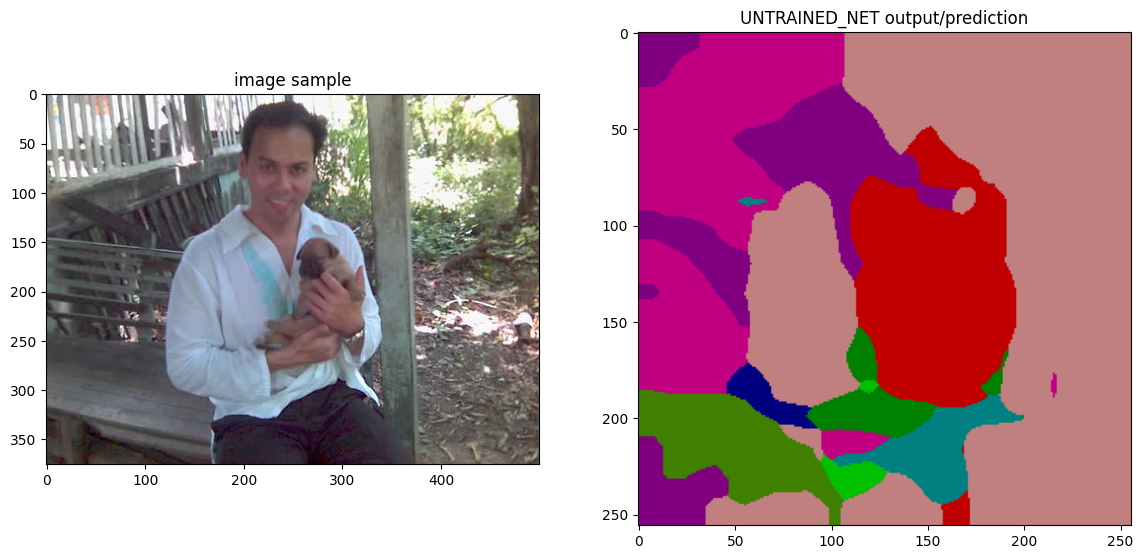

In [41]:
 # Test untrained model on sample image
untrained_net = DinoNuggets(dino_backbone, NUM_CLASSES).eval()
sample_img, _ = sanity_data[0]
sample_input, sample_data = sanity_dataset[0]

untrained_output = untrained_net.forward(sample_input.unsqueeze(0))
print(untrained_output.shape)
print(sample_data)

fig = plt.figure(figsize=(14,10))
ax = fig.add_subplot(1,2,1)
plt.title('image sample')
ax.imshow(sample_img)
ax = fig.add_subplot(1,2,2)
plt.title('UNTRAINED_NET output/prediction')

ax.imshow(colorize_mask(torch.argmax(untrained_output, dim=1).numpy()[0]))


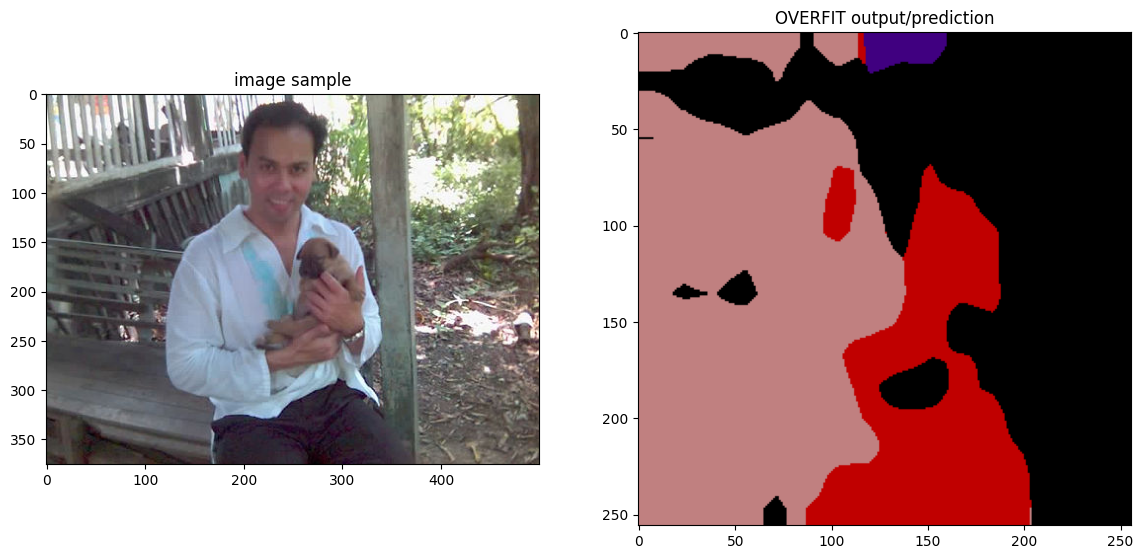

In [39]:
overfit_output = overfit_net.forward(sample_input[None])

fig = plt.figure(figsize=(14,10))
ax = fig.add_subplot(1,2,1)
plt.title('image sample')
ax.imshow(sample_img)
ax = fig.add_subplot(1,2,2)
plt.title('OVERFIT output/prediction')

if USE_GPU:
    ax.imshow(colorize_mask(torch.argmax(overfit_output, dim=1).cpu().numpy()[0]))
else:
    ax.imshow(colorize_mask(torch.argmax(overfit_output, dim=1).numpy()[0]))